In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

# Permet d'importer notre classe depuis le dossier src/
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.mlp_numpy import MLP

print("=== Chargement des données ===")
X_train = np.load("../donnees/features/X_train.npy")
X_val   = np.load("../donnees/features/X_val.npy")
X_test  = np.load("../donnees/features/X_test.npy")
y_train = np.load("../donnees/features/y_train.npy")
y_val   = np.load("../donnees/features/y_val.npy")
y_test  = np.load("../donnees/features/y_test.npy")

n_entree = X_train.shape[1]
n_classes = len(np.unique(y_train))

print(f"X_train : {X_train.shape}")
print(f"Dimensions : {n_entree} entrées → {n_classes} classes (langues)")

=== Chargement des données ===
X_train : (1050, 300)
Dimensions : 300 entrées → 3 classes (langues)


In [3]:
print("=== Lancement des tests d'hyperparamètres ===")
taux_a_tester = [0.01, 0.05, 0.1]
resultats = []

for taux in taux_a_tester:
    print(f"\nEntraînement avec taux d'apprentissage = {taux}...")
    np.random.seed(42) # Reproductibilité
    modele = MLP(n_entree=n_entree, n_classes=n_classes, taux_apprentissage=taux)
    modele.fit(X_train, y_train, X_val, y_val, n_epoques=100, taille_batch=32, verbose=False)
    
    acc_val = modele.calculer_accuracy(X_val, y_val)
    acc_test = modele.calculer_accuracy(X_test, y_test)
    loss_finale = modele.historique['train_loss'][-1]
    
    resultats.append({
        "Taux d'apprentissage": taux,
        "Époques": 100,
        "Train Loss finale": round(loss_finale, 4),
        "Val Accuracy": f"{acc_val*100:.1f}%",
        "Test Accuracy": f"{acc_test*100:.1f}%"
    })

# Création et affichage du tableau récapitulatif
df_resultats = pd.DataFrame(resultats)
print("\n=== TABLEAU DES RÉSULTATS (HYPERPARAMÈTRES) ===")
display(df_resultats)

=== Lancement des tests d'hyperparamètres ===

Entraînement avec taux d'apprentissage = 0.01...

Entraînement avec taux d'apprentissage = 0.05...

Entraînement avec taux d'apprentissage = 0.1...

=== TABLEAU DES RÉSULTATS (HYPERPARAMÈTRES) ===


,Taux d'apprentissage,Époques,Train Loss finale,Val Accuracy,Test Accuracy
0,0.01,100,1.0792,30.7%,30.2%
1,0.05,100,0.5764,99.6%,98.2%
2,0.10,100,0.2611,100.0%,99.1%


In [4]:
print("=== Entraînement du modèle final optimisé ===")
np.random.seed(42)
meilleur_modele = MLP(n_entree=n_entree, n_classes=n_classes, taux_apprentissage=0.1)

# On lance sur 200 époques pour une convergence parfaite
meilleur_modele.fit(X_train, y_train, X_val, y_val, n_epoques=200, taille_batch=32, verbose=False)

acc_finale = meilleur_modele.calculer_accuracy(X_test, y_test)
print(f"Entraînement terminé. Précision sur le jeu de test : {acc_finale*100:.2f}%")

# Sauvegarde selon le plan
os.makedirs("../modeles", exist_ok=True)
meilleur_modele.sauvegarder("../modeles/mlp_final")

=== Entraînement du modèle final optimisé ===
Entraînement terminé. Précision sur le jeu de test : 99.56%
Modèle sauvegardé : ../modeles/mlp_final.npz


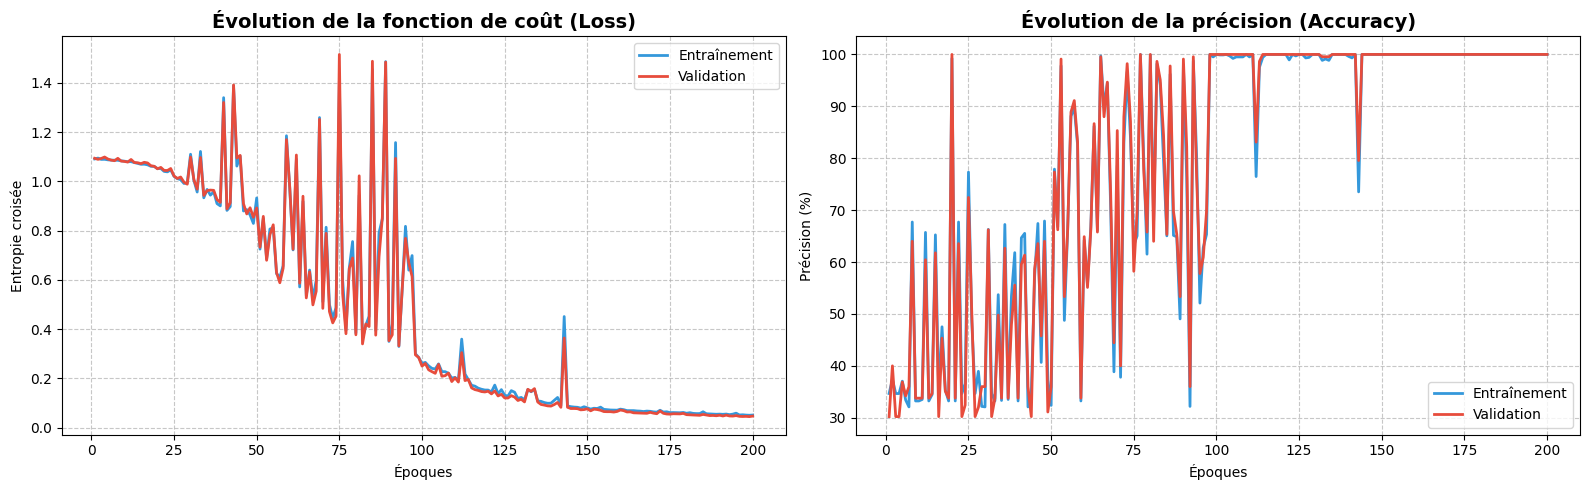

Graphiques de convergence sauvegardés sous 'courbes_convergence.png'


In [5]:
# Récupération de l'historique
historique = meilleur_modele.historique
epoques = range(1, len(historique['train_loss']) + 1)

# Création de la figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Graphique 1 : Fonction de Coût (Loss)
ax1.plot(epoques, historique['train_loss'], label='Entraînement', color='#3498db', linewidth=2)
ax1.plot(epoques, historique['val_loss'], label='Validation', color='#e74c3c', linewidth=2)
ax1.set_title('Évolution de la fonction de coût (Loss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Époques')
ax1.set_ylabel('Entropie croisée')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Graphique 2 : Précision (Accuracy)
ax2.plot(epoques, [acc * 100 for acc in historique['train_acc']], label='Entraînement', color='#3498db', linewidth=2)
ax2.plot(epoques, [acc * 100 for acc in historique['val_acc']], label='Validation', color='#e74c3c', linewidth=2)
ax2.set_title('Évolution de la précision (Accuracy)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Époques')
ax2.set_ylabel('Précision (%)')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.savefig('courbes_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphiques de convergence sauvegardés sous 'courbes_convergence.png'")